<a href="https://colab.research.google.com/github/shijithpulikkal/Exploratory-Data-Analysis/blob/main/06_telco_churn_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(
    '/content/drive/My Drive/Colab Notebooks/EDA/WA_Fn-UseC_-Telco-Customer-Churn.csv'
)

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
# TotalCharges is object dtype - investigate why
df['TotalCharges'].apply(type).value_counts()

,count
TotalCharges,
<class 'str'>,7043


In [8]:
# Find blank/whitespace entries
blank_mask = df['TotalCharges'].str.strip() == ''
print(blank_mask.sum())
df[blank_mask][['customerID', 'tenure', 'TotalCharges']]

11


,customerID,tenure,TotalCharges
488,4472-LVYGI,0,
753,3115-CZMZD,0,
936,5709-LVOEQ,0,
1082,4367-NUYAO,0,
1340,1371-DWPAZ,0,
3331,7644-OMVMY,0,
3826,3213-VVOLG,0,
4380,2520-SGTTA,0,
5218,2923-ARZLG,0,
6670,4075-WKNIU,0,


In [9]:
# These are new customers with tenure = 0 - makes sense they have no total charges yet
# Convert to numeric, coercing blanks to NaN, then fill with 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

df['TotalCharges'].describe()

,TotalCharges
count,7043.000000
mean,2279.734304
std,2266.794470
min,0.000000
25%,398.550000
50%,1394.550000
75%,3786.600000
max,8684.800000


In [10]:
# Check missing values overall
df.isnull().sum().sort_values(ascending=False)


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [11]:
# Check duplicates
print(df.duplicated().sum())
df.duplicated(subset='customerID').sum()

0


np.int64(0)

In [12]:
# SeniorCitizen: convert 0/1 to labeled category
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
df['SeniorCitizen'].value_counts()

,count
SeniorCitizen,
No,5901
Yes,1142


In [13]:
# Standardize "No internet service" / "No phone service" to "No"
cols_to_fix = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']

for col in cols_to_fix:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

df[cols_to_fix].head()

,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,No,Yes,No,No,No,No,No
1,Yes,No,Yes,No,No,No,No
2,Yes,Yes,No,No,No,No,No
3,Yes,No,Yes,Yes,No,No,No
4,No,No,No,No,No,No,No


In [14]:
# Drop customerID - not useful for analysis
df = df.drop(columns=['customerID'])

**3. Univariate Analysis**

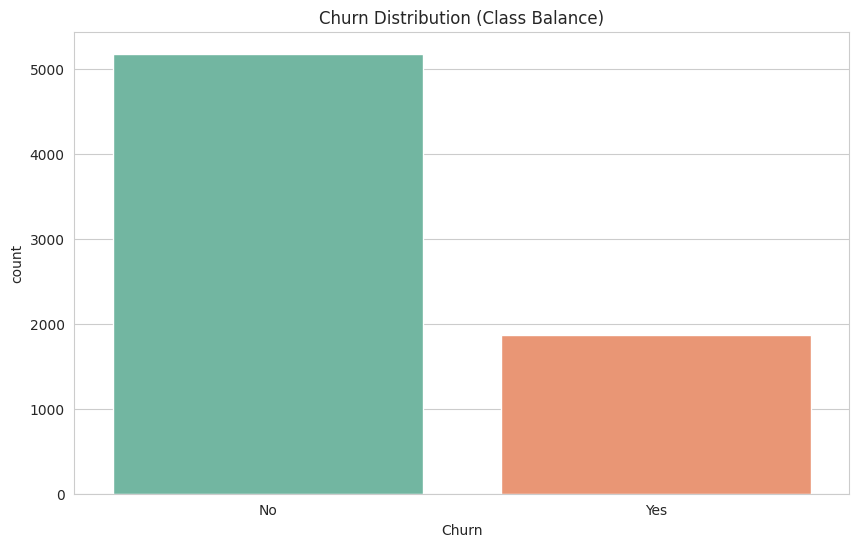

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [15]:
# Churn distribution (target) - check class balance
sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False)
plt.title('Churn Distribution (Class Balance)')
plt.show()

print(df['Churn'].value_counts(normalize=True) * 100)

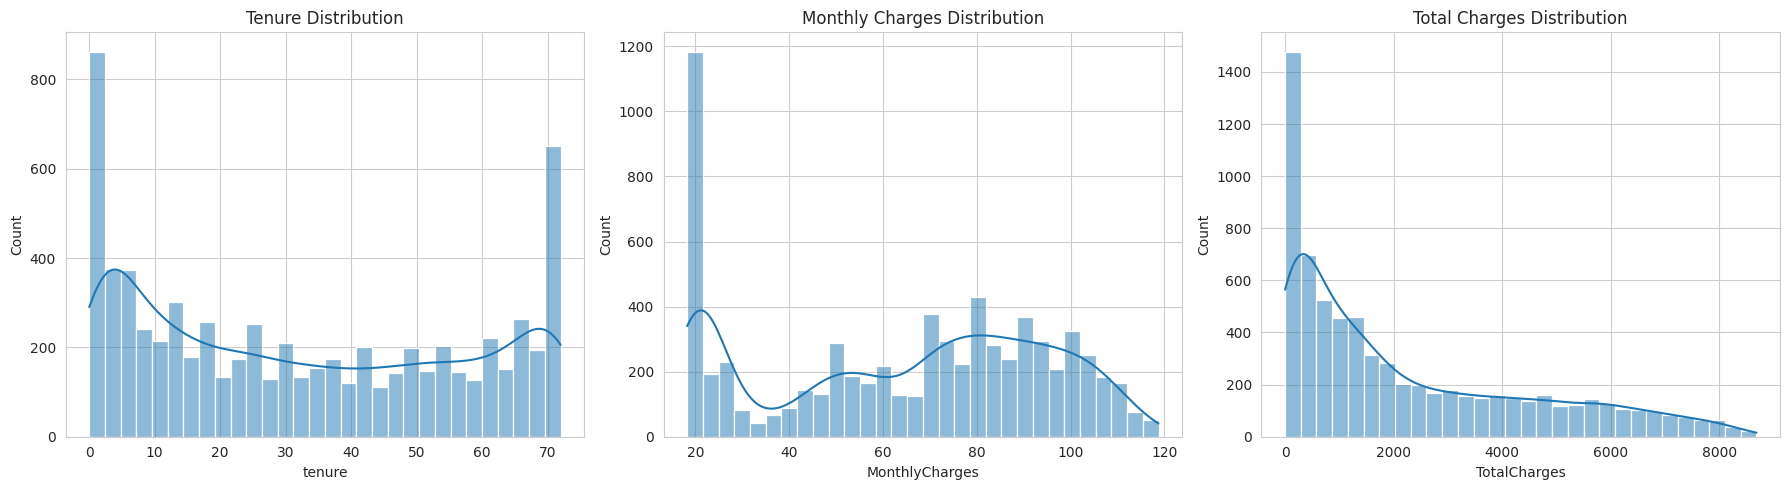

In [16]:
# Tenure, MonthlyCharges, TotalCharges distributions
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(df['tenure'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Tenure Distribution')

sns.histplot(df['MonthlyCharges'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Monthly Charges Distribution')

sns.histplot(df['TotalCharges'], bins=30, kde=True, ax=axes[2])
axes[2].set_title('Total Charges Distribution')

plt.tight_layout()
plt.show()

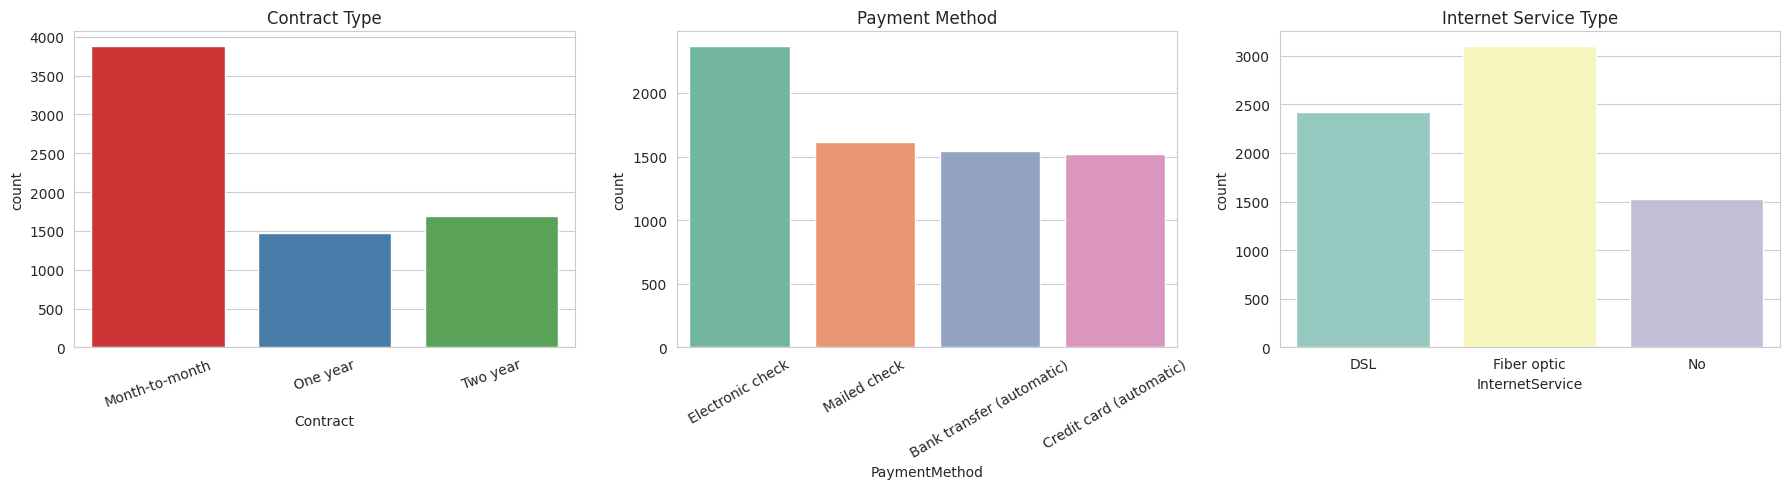

In [17]:
# Contract, PaymentMethod, InternetService distributions
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.countplot(data=df, x='Contract', hue='Contract', palette='Set1', legend=False, ax=axes[0])
axes[0].set_title('Contract Type')
axes[0].tick_params(axis='x', rotation=20)

sns.countplot(data=df, x='PaymentMethod', hue='PaymentMethod', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Payment Method')
axes[1].tick_params(axis='x', rotation=30)

sns.countplot(data=df, x='InternetService', hue='InternetService', palette='Set3', legend=False, ax=axes[2])
axes[2].set_title('Internet Service Type')

plt.tight_layout()
plt.show()

**4. Churn-Based Comparison Analysis**

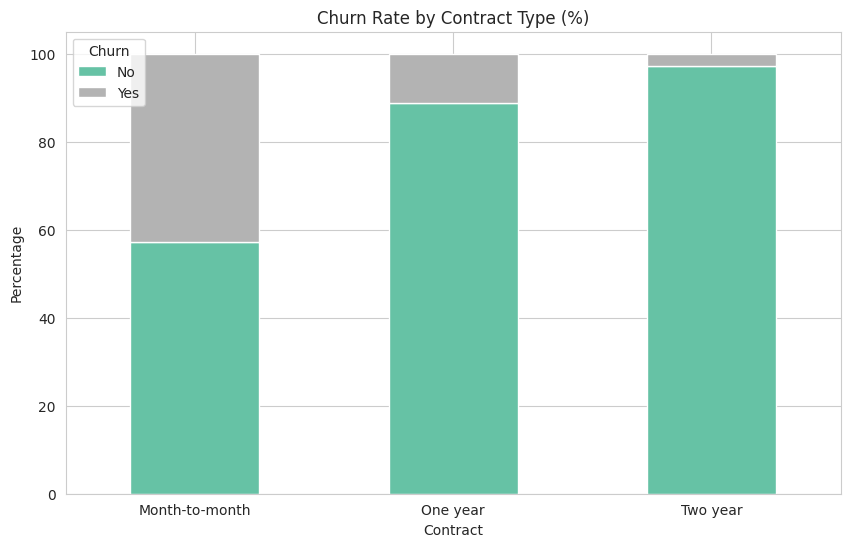

In [18]:
# Churn rate by Contract type
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

contract_churn.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Set2')
plt.title('Churn Rate by Contract Type (%)')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

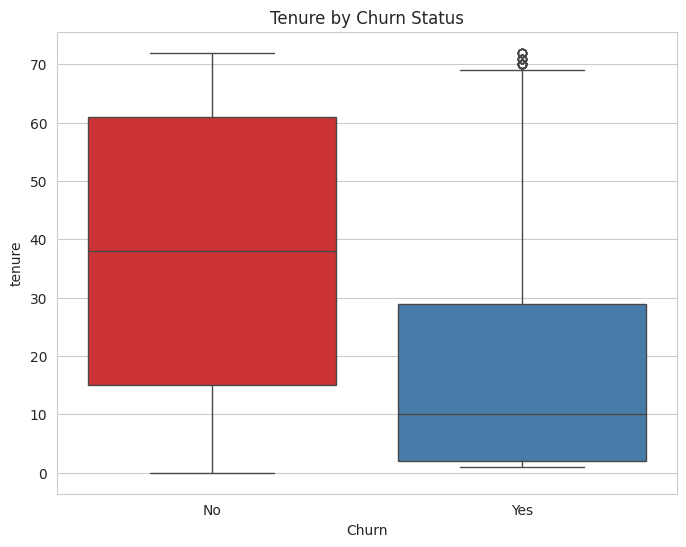

In [19]:
# Churn by tenure - boxplot
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='Churn', y='tenure', hue='Churn', palette='Set1', legend=False)
plt.title('Tenure by Churn Status')
plt.show()

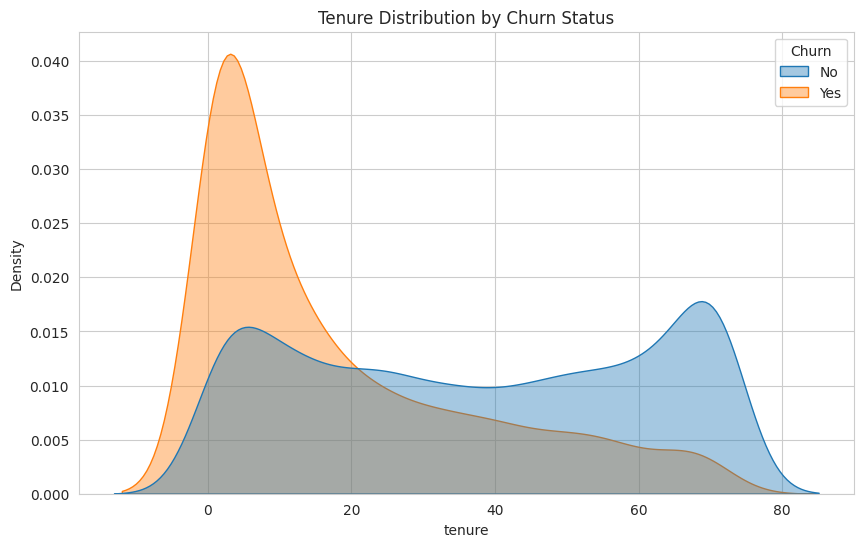

In [20]:
# Tenure distribution split by churn - KDE view
plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False, alpha=0.4)
plt.title('Tenure Distribution by Churn Status')
plt.show()

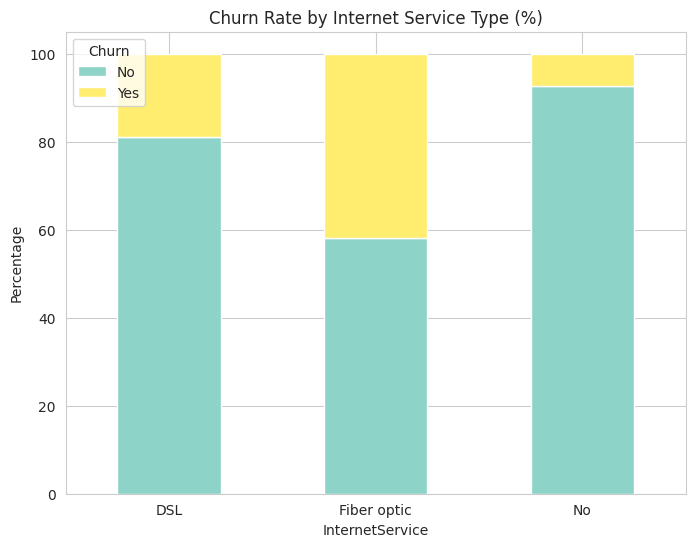

In [21]:
# Churn rate by InternetService
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100

internet_churn.plot(kind='bar', stacked=True, figsize=(8,6), colormap='Set3')
plt.title('Churn Rate by Internet Service Type (%)')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

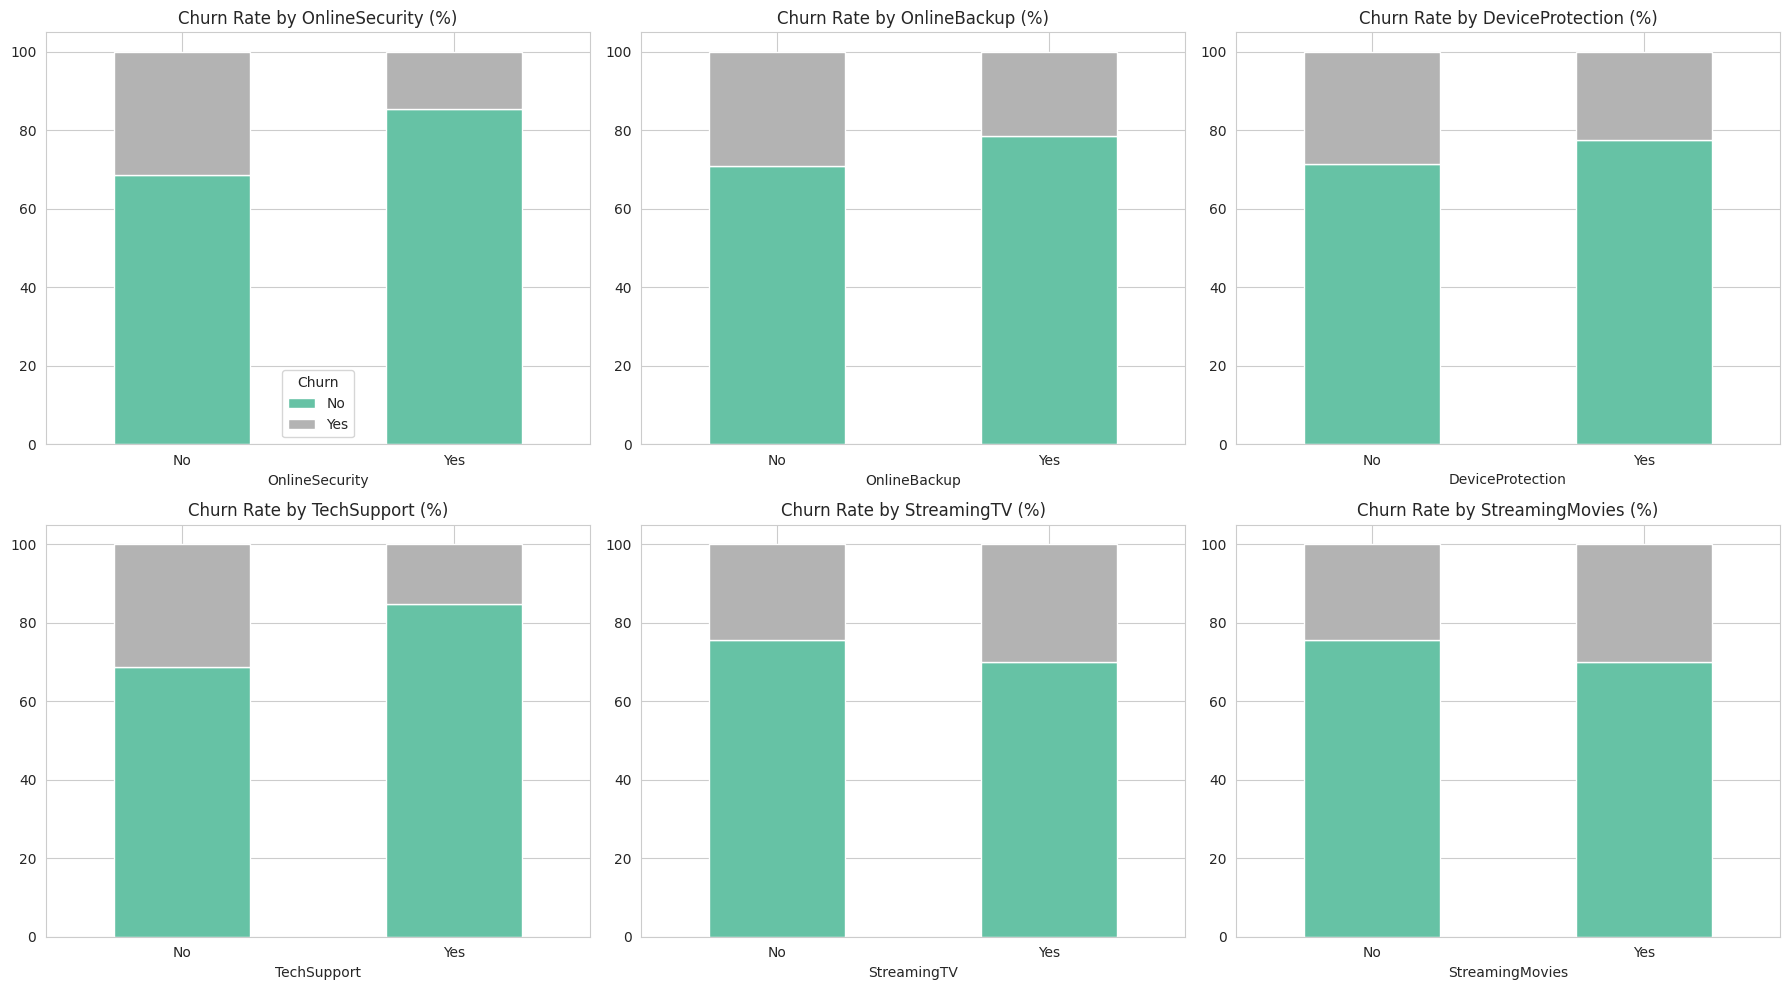

In [22]:
# Churn rate across add-on services
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(2, 3, figsize=(18,10))
axes = axes.flatten()

for i, col in enumerate(addon_cols):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='Set2', legend=(i==0))
    axes[i].set_title(f'Churn Rate by {col} (%)')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

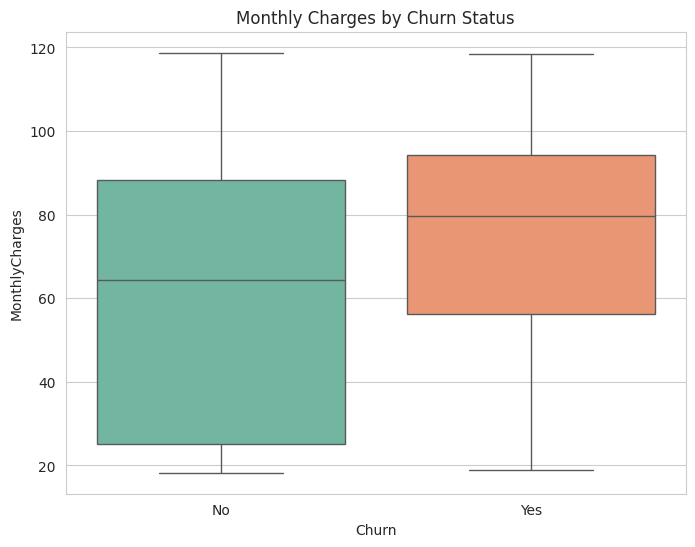

In [23]:
# MonthlyCharges by churn status
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', palette='Set2', legend=False)
plt.title('Monthly Charges by Churn Status')
plt.show()

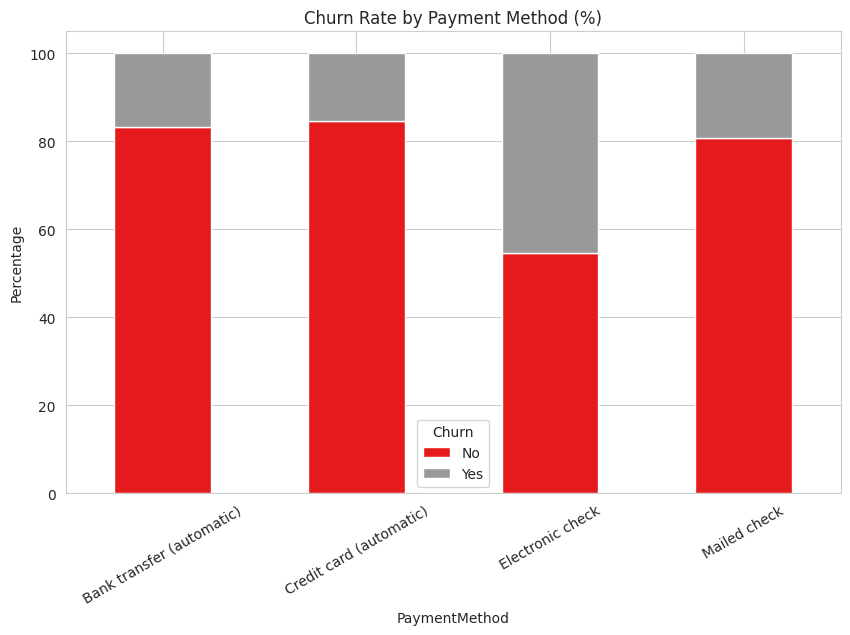

In [24]:
# Churn rate by PaymentMethod
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100

payment_churn.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Set1')
plt.title('Churn Rate by Payment Method (%)')
plt.ylabel('Percentage')
plt.xticks(rotation=30)
plt.legend(title='Churn')
plt.show()

**5. Multivariate / ML-Readiness Analysis**

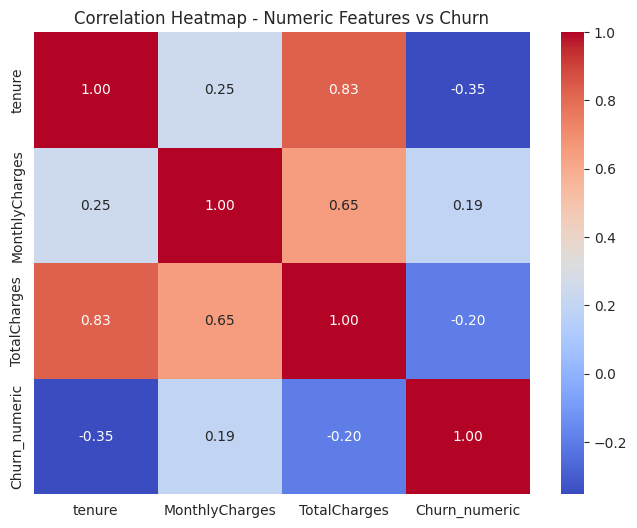

In [25]:
# Encode churn as numeric for correlation
df['Churn_numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_numeric']

plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Numeric Features vs Churn')
plt.show()

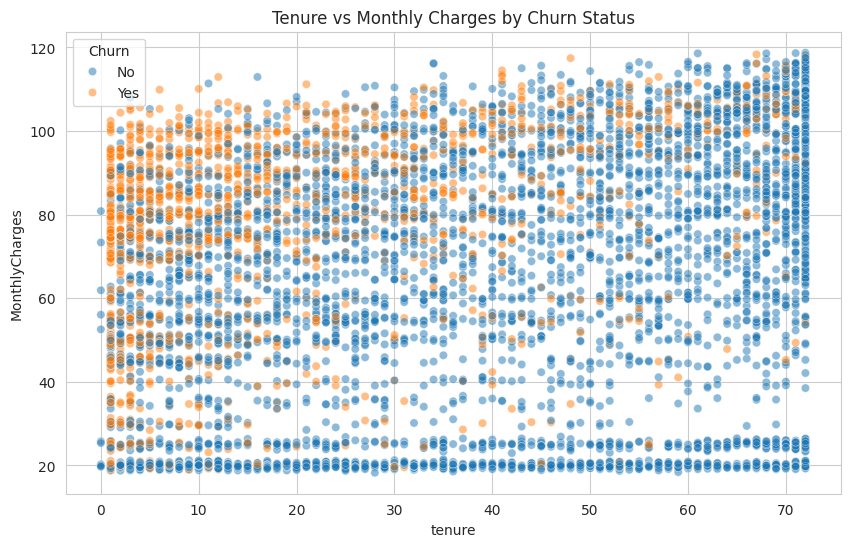

In [26]:
# Tenure vs MonthlyCharges, colored by churn
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', alpha=0.5)
plt.title('Tenure vs Monthly Charges by Churn Status')
plt.show()

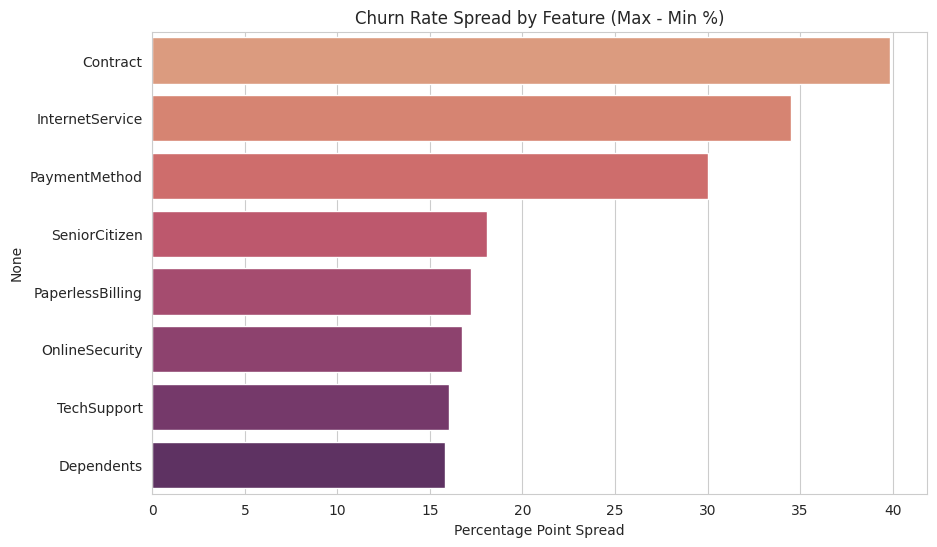

In [27]:
# Feature relevance summary - churn rate spread across categorical features
categorical_features = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport',
                          'OnlineSecurity', 'PaperlessBilling', 'SeniorCitizen', 'Dependents']

spread_summary = {}
for col in categorical_features:
    churn_rates = df.groupby(col)['Churn_numeric'].mean() * 100
    spread_summary[col] = churn_rates.max() - churn_rates.min()

spread_df = pd.Series(spread_summary).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=spread_df.values, y=spread_df.index, hue=spread_df.index, palette='flare', legend=False)
plt.title('Churn Rate Spread by Feature (Max - Min %)')
plt.xlabel('Percentage Point Spread')
plt.show()

In [28]:
# Class imbalance check
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print("Class distribution:")
print(churn_pct)
print(f"\nImbalance ratio: {churn_pct['No'] / churn_pct['Yes']:.2f} : 1")

Class distribution:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

Imbalance ratio: 2.77 : 1


**6. Insights Summary + Next Steps**

## Key Insights

- Month-to-month contracts have a dramatically higher churn rate than one- or two-year contracts — contract type is likely the single strongest churn driver.
- Customers with low tenure churn far more than long-tenured customers, suggesting the first few months are the highest-risk period.
- Customers without tech support or online security add-ons churn more, hinting these services may increase stickiness.
- Fiber optic internet customers show a higher churn rate than DSL or no-internet customers — possibly linked to pricing or service quality.
- Electronic check payment method is associated with higher churn compared to automatic payment methods.
- The dataset has moderate class imbalance (~[X]% churn vs ~[100-X]% no churn), which matters for modeling.
- [Add 1-2 more insights specific to what you observed]

## If I Were to Model This

- **Target:** `Churn` (binary classification)
- **Strongest predictive signals from EDA:** Contract type, tenure, and internet/add-on service features show the clearest separation between churn and non-churn customers.
- **Preprocessing needed:** One-hot encode categorical columns (Contract, PaymentMethod, InternetService, etc.); scale numeric features (tenure, MonthlyCharges, TotalCharges) for distance-based models.
- **Class imbalance:** With roughly [X]:[Y] imbalance, accuracy alone would be misleading. Would use class weights, SMOTE, or evaluate with precision/recall/F1/ROC-AUC instead.
- **Candidate models:** Logistic Regression (interpretable baseline) → Random Forest / Gradient Boosting (likely better performance, plus feature importance to confirm EDA findings).